In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
%cd '/content/drive/MyDrive/deep-orderbook-master/'

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import os
import gc

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
paths = 'coinbase_btc_usd/coinbase/btc_usd/l2_snapshots/100ms/'

In [ ]:
def concat_data(base_path):
    """Concatenate all the files in basepath keeping only the
    columns specified by features.
    """
    l2_snapshot = pd.DataFrame()
    for i, x in enumerate(tqdm(sorted(os.listdir(base_path)))):
        if base_path is None:
            path = x
        else:
            path = base_path + x
        df_hour = pd.read_parquet(path)
        l2_snapshot = pd.concat([l2_snapshot, df_hour.dropna()])

    return l2_snapshot

def extend_matrix(A, n):
    """Extend a matrix A by duplicating rows as specified by the list n."""
    #
    A_extended = np.empty((0, A.shape[1])) # initialize an empty array with the correct number of columns
    for i in range(len(n)): # iterate over the days
        A_extended = np.concatenate([A_extended, np.tile(A[i], (n[i], 1))]) # repeat the row for each day the correct number of times
    return A_extended


def normalise_data_per_day(df):
    df_mean = df.resample('D').mean()
    df_var = df.resample('D').var()

    timestamps_per_day = np.unique(df.index.date, return_counts=True)[1]

    # Calculate mean_array and var_array BEFORE dropping the first day's data
    mean_array = extend_matrix(df_mean.to_numpy(), timestamps_per_day)
    var_array = extend_matrix(df_var.to_numpy(), timestamps_per_day)

    # Drop the rows of the first day from BOTH df AND the extended arrays
    first_day = df.index[0].date()
    df = df[df.index.date != first_day]

    # Recalculate timestamps_per_day to align with the updated df
    timestamps_per_day = np.unique(df.index.date, return_counts=True)[1]

    # Update mean_array and var_array using the new timestamps_per_day:
    mean_array = extend_matrix(df_mean.to_numpy(), timestamps_per_day)
    var_array = extend_matrix(df_var.to_numpy(), timestamps_per_day)

    # slice mean_array and var_array
    df = (df - mean_array) / np.sqrt(var_array)

    return df

def balance_classes(y):
    unique = np.unique(y, return_counts=True)

    # Take smallest number as class size
    class_size = np.min(unique[1])
    class_size_index = np.argmin(unique[1])
    timestamps = np.array([], dtype=int)
    for i, category in enumerate(unique[0]):
        if i == class_size_index:
            continue
        index = np.argwhere(y==category)
        index = index.reshape(len(index))
        random_timestamps = np.random.choice(index, (unique[1][i] - class_size), replace=False)
        timestamps = np.concatenate((timestamps, random_timestamps), axis=None)

    return timestamps

def generate_y(df_snapshot, T=100, D=40, best_ask='a1', best_bid='b1', k=20, alpha=10e-5):
    """Return X, y from the snapshot dataframe and the best ask/bid columns."""
    df = pd.DataFrame()
    df['mid_price'] = (df_snapshot[best_ask].to_numpy()+df_snapshot[best_bid].to_numpy())/2

    # Create columns delayed by -k to k-1
    for i in range(-k, k):
        df[i] = df['mid_price'].shift(periods=i)

    # Drop first k-1 rows and last k rows
    df.drop(range(0,20), axis=0, inplace=True)
    df.drop(range(len(df_snapshot)-20,len(df_snapshot)), axis=0, inplace=True)

    # Compute mean of previous k and next k
    df['m_b'] = df[range(0,20)].mean(axis=1)
    df['m_a'] = df[range(-20,0)].mean(axis=1)

    # Compute label of increasing or decreasing
    y_increase = np.where(df['m_b'] > df['m_a'] * (1+alpha), 1, 0)
    y_decrease = np.where(df['m_b'] < df['m_a'] * (1-alpha), -1, 0)
    y = y_increase + y_decrease

    # 100 most recent limit orders used so ignore first 100 timesteps
    y = y[T:]
    y += 1

    return y

def generate_preX(df_snapshot):
    preX = df_snapshot.to_numpy()[20:-20]

    return preX

def generate_X(preX, T=100, D=40):
    # For each timestep create matrix of 100 most recent limit orders
    X = np.array([preX[t:t+T] for t in range(len(preX)-T)], dtype='float32')

    return X

In [ ]:
#l2_snap = pd.read_csv('total.csv', index_col=0)

In [ ]:
#l2_snap.head()

In [ ]:
#print(os.getcwd())

In [ ]:
#df_snapshot = pd.read_parquet(paths + "coinbase_btc_usd_l2_book_snapshots_depth50_2019_11_12_0000_0100.parquet")
#df_ticker = pd.read_parquet('/content/drive/MyDrive/deep-orderbook-master/coinbase_btc_usd/coinbase/btc_usd/ticker/coinbase_btc_usd_ticker_2019_11_12.parquet')
#df_trades = pd.read_parquet('/content/drive/MyDrive/deep-orderbook-master/coinbase_btc_usd/coinbase/btc_usd/trades/coinbase_btc_usd_trades_2019_11_12.parquet')

In [ ]:
#df_snapshot.head()

In [ ]:
register = {}

In [ ]:
l2_snapshot = pd.DataFrame()

In [ ]:
count = 0
day = pd.DataFrame()
i = 0
for x in os.listdir(paths):
    path = paths+x
    temp = pd.read_parquet(path)
    if count%24 == 0:
        day = pd.read_parquet(path)
    else:
        day = pd.concat([day,temp])

    i+=1
    count +=1

    if count%24 == 0:
        flag = not register
        day = day.dropna()
        print(day.shape)
        result = []
        for cols in day.columns:
            values = day[cols].to_numpy()
            mean = np.mean(values)
            std = np.std(values)
            result.append([cols,[mean,std]])
        register[count/24] = result
        if not flag:
            for l in range(200):
                prev_stat = register[(count/24)-1]
                col_name = prev_stat[l][0]
                col_mean = prev_stat[l][1][0]
                col_std = prev_stat[l][1][1]
                values = day[col_name].to_numpy()
                values = (values - col_mean)/col_std
                day[col_name] = values
            l2_snapshot = pd.concat([day,l2_snapshot])
        del day

    if i>240:
        break

In [ ]:
l2_snapshot.shape

In [ ]:
#print(os.getcwd())
# Write to CSV files
##l2_snapshot.to_csv("total_data.csv", index=False)
#print("Data successfully written to CSV files.")

## Generic Model and Depth Data Generation

In [16]:
#!pip install pytorch-tcn

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils import weight_norm
from pytorch_tcn import TCN

ModuleNotFoundError: No module named 'pytorch_tcn'

In [ ]:
class TCNClassifier(nn.Module):
    def __init__(self, depth, output_size=3, dropout=0.4):
        super(TCNClassifier, self).__init__()

        # Define the TCN layer
        self.tcn = TCN(
            num_inputs=depth,
            num_channels=[64,64,64,64,64,64,64],
            kernel_size=7,
            dilations=[1, 2, 4, 8, 16, 32, 64], # Adjust dilations if needed
            dropout=dropout, # Provide dropout rate here
            causal=True,  # Padding type (causal is common for time series)
            use_norm='weight_norm',
            activation= 'relu',
            kernel_initializer='xavier_uniform',
            use_skip_connections=True, # Enable skip connections
            input_shape='NCL',
            embedding_mode='add',
            use_gate=False,
            lookahead=0
        )

        # Final linear layer (Dense in TensorFlow)
        self.fc = nn.Linear(64, output_size)

    def forward(self, x):
        #print("x.shape at beginning of forward:", x.shape)
        x = x.permute(0, 2, 1)  # Adjust shape to match PyTorch TCN
        x = self.tcn(x)
        #print("X.shape after tcn:", x.shape)
        x = x[:, :, -1]  # Take the last output for classification
        #print("X.shape before fc:", x.shape)
        x = self.fc(x)  # Final classification layer
        return x  # Softmax is applied during loss computation

# Function to generate model (similar to TensorFlow's `generate_model(depth)`)
def generate_model(depth):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # Initialize model
    model = TCNClassifier(depth=depth).to(device)
    # Define optimizer (Adam with learning rate 0.001)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    # Loss function (equivalent to sparse_categorical_crossentropy)
    criterion = nn.CrossEntropyLoss()

    return model, optimizer, criterion

In [ ]:
def generate_data(l2_snap, depth, columns):
    l2_snap.index = pd.to_datetime(l2_snap.index)
    l2_snap_dep2 = l2_snap.loc[:,columns]
    l2_norm = normalise_data_per_day(l2_snap_dep2)
    T = 100
    D = depth
    y = generate_y(l2_norm, T=T, D=D, best_ask='a1', best_bid = 'b1', alpha=0.002)
    preX = generate_preX(l2_norm)
    print("preX Shape: ", preX.shape)
    X = generate_X(preX)
    print("X shape, y shape: ", X.shape, y.shape)
    print("Unique y's: ", np.unique(y))

    del preX
    gc.collect()

    # First and last 20 are removed to create labels and then last 100 as previous 100 is required for input matrix
    X_index = l2_norm[20:-120].index

    # Number of data points for the last day
    num_test = np.unique(X_index.day, return_counts=True)[1][-1]

    # Split the data into the first seven days and the last day
    X_train_val = X[:-num_test]
    y_train_val = y[:-num_test]
    X_test = X[-num_test:]
    y_test = y[-num_test:]
    return X_train_val, y_train_val, X_test, y_test

## DEPTH 1

In [28]:
l2_snap = l2_snapshot

In [29]:
X_train_val, y_train_val, X_test, y_test = generate_data(l2_snap, 4, columns=['b1','a1','bq1','aq1'])

preX Shape:  (3823317, 4)
X shape, y shape:  (3823217, 100, 4) (3823217,)
Unique y's:  [0 1 2]


In [30]:
#m = generate_model(4)
model, optimizer, criterion = generate_model(4)

In [23]:
#from sklearn.utils.class_weight import compute_class_weight
#class_weights = compute_class_weight('balanced', np.unique(y_train_val), y_train_val)
#d_class_weights = dict(enumerate(class_weights))
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [31]:
# Define training parameters
EPOCHS = 20
batch_size = 128

# Convert datasets to PyTorch tensors
X_train_tensor = torch.tensor(X_train_val, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create DataLoaders
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

# Initialize model, optimizer, and loss function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0,1.0,1.0])).to(device)

# Learning rate scheduler (ReduceLROnPlateau equivalent)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=0.0001)

# Training loop with early stopping & checkpointing
best_val_loss = float('inf')
patience, patience_counter = 4, 0  # Early stopping params

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        #print("X_batch shape:", X_batch.shape)
        #print("y_batch shape:", y_batch.shape)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation step
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_val_batch, y_val_batch in test_loader:
            X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
            val_output = model(X_val_batch)
            val_loss += criterion(val_output, y_val_batch).item()

    # Adjust learning rate if necessary
    scheduler.step(val_loss)

    # Save best model based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "model_resnet_walkforward_tcn1.pth")
        print(f"Epoch {epoch}: 🔥 Best model saved!")

    # Early stopping logic
    if val_loss >= best_val_loss:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"⏳ Early stopping triggered at epoch {epoch}")
            # break
    else:
        patience_counter = 0  # Reset patience counter if loss improves

    print(f"Epoch {epoch}: Training Loss = {running_loss:.4f}, Validation Loss = {val_loss:.4f}")

print("Training complete!")

Epoch 0: 🔥 Best model saved!
Epoch 0: Training Loss = 11050.3520, Validation Loss = 2282.7223
Epoch 1: 🔥 Best model saved!
Epoch 1: Training Loss = 10613.9583, Validation Loss = 2157.4195
Epoch 2: Training Loss = 10504.7800, Validation Loss = 2258.5263
⏳ Early stopping triggered at epoch 3
Epoch 3: Training Loss = 10431.6402, Validation Loss = 2253.2252
Epoch 4: 🔥 Best model saved!
⏳ Early stopping triggered at epoch 4
Epoch 4: Training Loss = 10355.6046, Validation Loss = 2136.8327
⏳ Early stopping triggered at epoch 5
Epoch 5: Training Loss = 10285.4056, Validation Loss = 2147.8873
Epoch 6: 🔥 Best model saved!
⏳ Early stopping triggered at epoch 6
Epoch 6: Training Loss = 10210.5928, Validation Loss = 2115.4843
⏳ Early stopping triggered at epoch 7
Epoch 7: Training Loss = 10110.3386, Validation Loss = 2208.9852
⏳ Early stopping triggered at epoch 8
Epoch 8: Training Loss = 10040.0646, Validation Loss = 2226.7876
Epoch 9: 🔥 Best model saved!
⏳ Early stopping triggered at epoch 9
Epoc

In [32]:
#y_pred = m.predict(X_test).argmax(axis=1)
y_pred = []  # Initialize empty list to store predictions
for X_batch, y_batch in test_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # Move to GPU if available
    predictions = model(X_batch).argmax(dim=1)
    y_pred.extend(predictions.cpu().numpy())  # Convert to NumPy and store

# Convert list to NumPy array if needed
y_pred = np.array(y_pred)
print("Stored predictions:", y_pred.shape)

Stored predictions: (465520,)


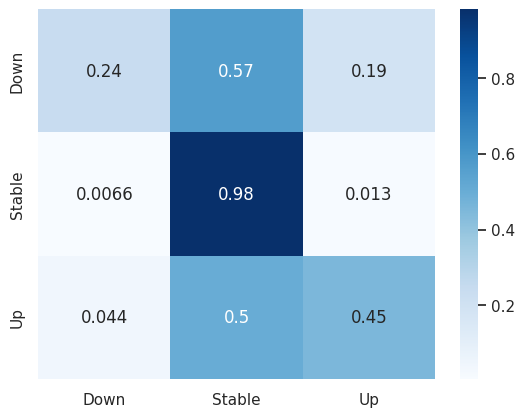

In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
cm = confusion_matrix(y_pred=y_pred, y_true=y_test)

cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

ax=sns.heatmap(cm, annot=True, xticklabels=['Down','Stable','Up'], yticklabels=['Down','Stable','Up'], cmap='Blues')
ax.set_ylim(3.0, 0)
plt.savefig('image_depth_1')

In [34]:
from sklearn.metrics import classification_report
print(classification_report(y_true = y_test,y_pred = y_pred,  target_names=['Down', 'Stable', 'Up']))

              precision    recall  f1-score   support

        Down       0.75      0.24      0.36     61912
      Stable       0.83      0.98      0.90    341588
          Up       0.64      0.45      0.53     62020

    accuracy                           0.81    465520
   macro avg       0.74      0.56      0.60    465520
weighted avg       0.80      0.81      0.78    465520



## Depth:10

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [21]:
selected = round(l2_snapshot.shape[0]*0.4)

In [22]:
X_train_val, y_train_val, X_test, y_test = generate_data(l2_snapshot.iloc[:selected,:], 40, columns = ['b1','b2','b3','b4','b5','b6','b7','b8', 'b9', 'b10', 'a1','a2','a3','a4','a5','a6','a7','a8', 'a9', 'a10', 'bq1','bq2','bq3','bq4','bq5','bq6','bq7','bq8', 'bq9', 'bq10', 'aq1','aq2','aq3','aq4','aq5','aq6','aq7','aq8', 'aq9', 'aq10'] )

preX Shape:  (1181122, 40)
X shape, y shape:  (1181022, 100, 40) (1181022,)
Unique y's:  [0 1 2]


In [23]:
del l2_snapshot

In [24]:
#m = generate_model(40)
import numpy as np
import torch
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_val), y=y_train_val)
d_class_weights = dict(enumerate(class_weights))
class_weights_tensor = torch.tensor(list(d_class_weights.values()), dtype=torch.float32).to(device)

In [25]:
class_weights_tensor

tensor([2.7570, 0.4362, 2.9005], device='cuda:0')

In [26]:
model, optimizer, criterion = generate_model(40)

In [27]:
# Define training parameters
EPOCHS = 20
batch_size = 128

# Convert datasets to PyTorch tensors
X_train_tensor = torch.tensor(X_train_val, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create DataLoaders
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

# Initialize model, optimizer, and loss function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor).to(device)

# Learning rate scheduler (ReduceLROnPlateau equivalent)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=0.0001)

# Training loop with early stopping & checkpointing
best_val_loss = float('inf')
patience, patience_counter = 4, 0  # Early stopping params

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        #print("X_batch shape:", X_batch.shape)
        #print("y_batch shape:", y_batch.shape)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation step
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_val_batch, y_val_batch in test_loader:
            X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
            val_output = model(X_val_batch)
            val_loss += criterion(val_output, y_val_batch).item()

    # Adjust learning rate if necessary
    scheduler.step(val_loss)

    # Save best model based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "model_resnet_walkforward_tcn10.pth")
        print(f"Epoch {epoch}: 🔥 Best model saved!")

    # Early stopping logic
    if val_loss >= best_val_loss:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"⏳ Early stopping triggered at epoch {epoch}")
            # break
    else:
        patience_counter = 0  # Reset patience counter if loss improves

    print(f"Epoch {epoch}: Training Loss = {running_loss:.4f}, Validation Loss = {val_loss:.4f}")

print("Training complete!")

Epoch 0: 🔥 Best model saved!
Epoch 0: Training Loss = 7975.2603, Validation Loss = 1383.2520
Epoch 1: Training Loss = 6542.9970, Validation Loss = 1457.4038
Epoch 2: 🔥 Best model saved!
Epoch 2: Training Loss = 6445.5849, Validation Loss = 1262.2875
⏳ Early stopping triggered at epoch 3
Epoch 3: Training Loss = 6396.1107, Validation Loss = 1429.3062
⏳ Early stopping triggered at epoch 4
Epoch 4: Training Loss = 6178.3773, Validation Loss = 1622.9539
⏳ Early stopping triggered at epoch 5
Epoch 5: Training Loss = 6194.4068, Validation Loss = 1489.1938
⏳ Early stopping triggered at epoch 6
Epoch 6: Training Loss = 5772.7735, Validation Loss = 1536.3073
⏳ Early stopping triggered at epoch 7
Epoch 7: Training Loss = 5711.4494, Validation Loss = 1414.1621
⏳ Early stopping triggered at epoch 8
Epoch 8: Training Loss = 5654.3201, Validation Loss = 1667.8862
⏳ Early stopping triggered at epoch 9
Epoch 9: Training Loss = 5516.4502, Validation Loss = 1655.2449
⏳ Early stopping triggered at epoch 

In [46]:
#y_pred = m.predict(X_test).argmax(axis=1)
y_pred = []  # Initialize empty list to store predictions
for X_batch, y_batch in test_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # Move to GPU if available
    predictions = model(X_batch).argmax(dim=1)
    y_pred.extend(predictions.cpu().numpy())  # Convert to NumPy and store

# Convert list to NumPy array if needed
y_pred = np.array(y_pred)
print("Stored predictions:", y_pred.shape)

Stored predictions: (219183,)


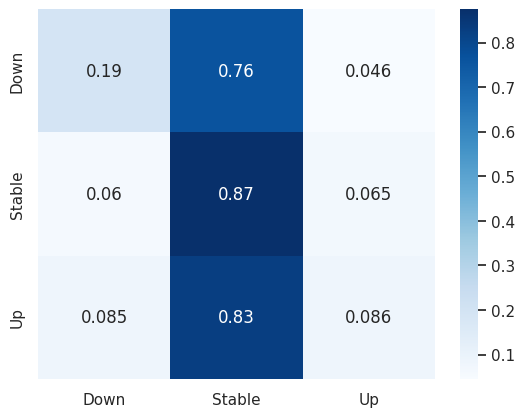

In [47]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
cm = confusion_matrix(y_pred=y_pred, y_true=y_test)

cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

ax=sns.heatmap(cm, annot=True, xticklabels=['Down','Stable','Up'], yticklabels=['Down','Stable','Up'], cmap='Blues')
ax.set_ylim(3.0, 0)
plt.savefig('image_depth_10')

In [48]:
from sklearn.metrics import classification_report
print(classification_report(y_true = y_test,y_pred = y_pred,  target_names=['Down', 'Stable', 'Up']))

              precision    recall  f1-score   support

        Down       0.38      0.19      0.26     37510
      Stable       0.69      0.87      0.77    146450
          Up       0.21      0.09      0.12     35223

    accuracy                           0.63    219183
   macro avg       0.43      0.38      0.38    219183
weighted avg       0.56      0.63      0.58    219183



## Depth 5

In [18]:
selected = l2_snapshot.iloc[:round(l2_snapshot.shape[0]*.8),:]

In [21]:
X_train_val, y_train_val, X_test, y_test = generate_data(l2_snap, 20, columns = ['b1','b2','b3','b4','b5', 'a1','a2','a3','a4','a5', 'bq1','bq2','bq3','bq4','bq5', 'aq1','aq2','aq3','aq4','aq5'] )

NameError: name 'generate_data' is not defined

In [20]:
import numpy as np
import torch
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_val), y=y_train_val)
d_class_weights = dict(enumerate(class_weights))
class_weights_tensor = torch.tensor(list(d_class_weights.values()), dtype=torch.float32).to(device)

NameError: name 'y_train_val' is not defined

In [52]:
# Define training parameters
EPOCHS = 20
batch_size = 128

# Convert datasets to PyTorch tensors
X_train_tensor = torch.tensor(X_train_val, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create DataLoaders
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

# Initialize model, optimizer, and loss function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0,1.0,1.0])).to(device)

# Learning rate scheduler (ReduceLROnPlateau equivalent)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=0.0001)

# Training loop with early stopping & checkpointing
best_val_loss = float('inf')
patience, patience_counter = 4, 0  # Early stopping params

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        #print("X_batch shape:", X_batch.shape)
        #print("y_batch shape:", y_batch.shape)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation step
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_val_batch, y_val_batch in test_loader:
            X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
            val_output = model(X_val_batch)
            val_loss += criterion(val_output, y_val_batch).item()

    # Adjust learning rate if necessary
    scheduler.step(val_loss)

    # Save best model based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "model_resnet_walkforward_tcn5.pth")
        print(f"Epoch {epoch}: 🔥 Best model saved!")

    # Early stopping logic
    if val_loss >= best_val_loss:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"⏳ Early stopping triggered at epoch {epoch}")
            # break
    else:
        patience_counter = 0  # Reset patience counter if loss improves

    print(f"Epoch {epoch}: Training Loss = {running_loss:.4f}, Validation Loss = {val_loss:.4f}")

print("Training complete!")

Epoch 0: 🔥 Best model saved!
Epoch 0: Training Loss = 1729.1742, Validation Loss = 10076.4098
Epoch 1: Training Loss = 1671.4895, Validation Loss = 13406.1050
Epoch 2: Training Loss = 1639.1175, Validation Loss = 39473.5976
⏳ Early stopping triggered at epoch 3
Epoch 3: Training Loss = 1620.4999, Validation Loss = 86290.1129
⏳ Early stopping triggered at epoch 4
Epoch 4: Training Loss = 1557.6601, Validation Loss = 92432.5084
⏳ Early stopping triggered at epoch 5
Epoch 5: Training Loss = 1541.6723, Validation Loss = 104402.9488
⏳ Early stopping triggered at epoch 6
Epoch 6: Training Loss = 1533.6180, Validation Loss = 104512.9602
⏳ Early stopping triggered at epoch 7
Epoch 7: Training Loss = 1496.6384, Validation Loss = 122059.0157
⏳ Early stopping triggered at epoch 8
Epoch 8: Training Loss = 1487.7764, Validation Loss = 146607.3189
⏳ Early stopping triggered at epoch 9
Epoch 9: Training Loss = 1479.4420, Validation Loss = 187710.3715
⏳ Early stopping triggered at epoch 10
Epoch 10: T

In [53]:
#y_pred = m.predict(X_test).argmax(axis=1)
y_pred = []  # Initialize empty list to store predictions
for X_batch, y_batch in test_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)  # Move to GPU if available
    predictions = model(X_batch).argmax(dim=1)
    y_pred.extend(predictions.cpu().numpy())  # Convert to NumPy and store

# Convert list to NumPy array if needed
y_pred = np.array(y_pred)
print("Stored predictions:", y_pred.shape)

Stored predictions: (219183,)


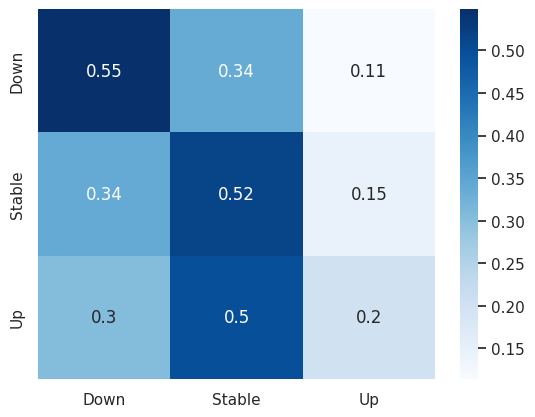

In [54]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
cm = confusion_matrix(y_pred=y_pred, y_true=y_test)

cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

ax=sns.heatmap(cm, annot=True, xticklabels=['Down','Stable','Up'], yticklabels=['Down','Stable','Up'], cmap='Blues')
ax.set_ylim(3.0, 0)
plt.savefig('image_depth_5')

In [55]:
from sklearn.metrics import classification_report
print(classification_report(y_true = y_test,y_pred = y_pred,  target_names=['Down', 'Stable', 'Up']))

              precision    recall  f1-score   support

        Down       0.25      0.55      0.35     37510
      Stable       0.71      0.52      0.60    146450
          Up       0.22      0.20      0.21     35223

    accuracy                           0.47    219183
   macro avg       0.39      0.42      0.38    219183
weighted avg       0.56      0.47      0.49    219183

